In [1]:
# ============================================================
# Celda 1: Importar librerías y configurar entorno
# ============================================================
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)

# Agregar carpeta raíz al path para importar 'src'
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from cargar_datos import cargar_dataset_recontacto_correcto
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    average_precision_score
)
from xgboost import XGBClassifier

# Configuración de gráficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✅ Librerías cargadas correctamente")
print("📚 Modelo entrenado con el dataset LIMPIO (después del MINI ETL)")


✅ Librerías cargadas correctamente
📚 Modelo entrenado con el dataset LIMPIO (después del MINI ETL)


In [2]:
# ============================================================
# Celda 2: Cargar dataset desde SQL Server
# ============================================================
print("=" * 70)
print("📊 CARGANDO DATASET CORREGIDO (LIMPIO, SIN DATA LEAKAGE)")
print("=" * 70)

df = cargar_dataset_recontacto_correcto()

if df is not None:
    print(f"\n✅ Dataset cargado exitosamente")
    print(f"📏 Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
else:
    print("❌ Error al cargar datos. Verifica que:")
    print("   1. El generador C# ya cargó el Data Warehouse")
    print("   2. El script 'sql/03_dataset_recontacto_limpio.sql' fue ejecutado")
    print("   3. La tabla dbo.dm_dataset_recontacto_correcto existe")


📊 CARGANDO DATASET CORREGIDO (LIMPIO, SIN DATA LEAKAGE)
📊 CARGANDO DATASET v1 CORREGIDO DE RECONTACTO (LIMPIO)



📏 Dataset v1 (limpio): 94,065 filas × 29 columnas

🎯 Distribución de la variable objetivo (recontacto_7_dias):
recontacto_7_dias
0    55324
1    38741
Name: count, dtype: int64

📈 Tasa de recontacto_7_dias=1: 41.19%

✅ Dataset cargado exitosamente
📏 Dimensiones: 94,065 filas × 29 columnas


🔍 EXPLORACIÓN INICIAL DEL DATASET

📋 Columnas del dataset (29):
    1. id_interaccion                 | Tipo: str        | Nulos: 0
    2. fecha_contacto                 | Tipo: object     | Nulos: 0
    3. recontacto_7_dias              | Tipo: int64      | Nulos: 0
    4. es_canal_chat                  | Tipo: int64      | Nulos: 0
    5. es_canal_correo                | Tipo: int64      | Nulos: 0
    6. es_canal_red_social            | Tipo: int64      | Nulos: 0
    7. es_motivo_falla                | Tipo: int64      | Nulos: 0
    8. es_motivo_cobro                | Tipo: int64      | Nulos: 0
    9. es_motivo_solicitud            | Tipo: int64      | Nulos: 0
   10. es_motivo_queja                | Tipo: int64      | Nulos: 0
   11. es_cola_facturacion            | Tipo: int64      | Nulos: 0
   12. es_cola_soporte                | Tipo: int64      | Nulos: 0
   13. es_cola_reclamos               | Tipo: int64      | Nulos: 0
   14. es_cola_tramites               | Tipo: int64 

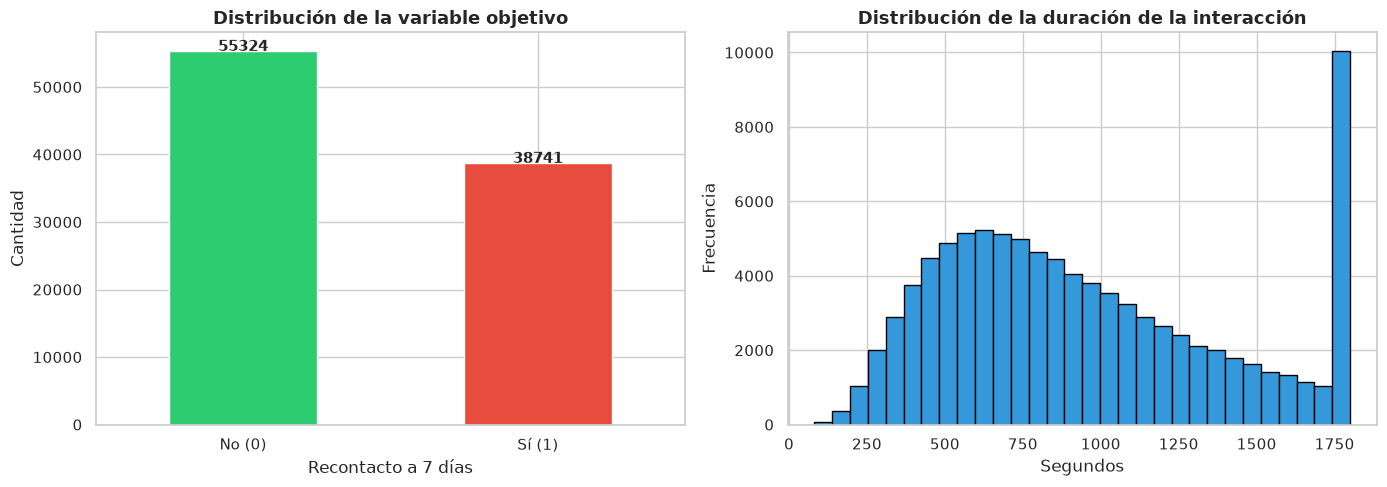

In [3]:
# ============================================================
# Celda 3: Exploración inicial del dataset
# ============================================================
print("=" * 70)
print("🔍 EXPLORACIÓN INICIAL DEL DATASET")
print("=" * 70)

print(f"\n📋 Columnas del dataset ({len(df.columns)}):")
for i, col in enumerate(df.columns, 1):
    tipo = df[col].dtype
    nulos = df[col].isnull().sum()
    print(f"   {i:2d}. {col:30s} | Tipo: {str(tipo):10s} | Nulos: {nulos}")

print(f"\n🎯 Distribución de la variable objetivo (recontacto_7_dias):")
target_counts = df['recontacto_7_dias'].value_counts()
print(target_counts)
print(f"\n📈 Tasa de recontacto (TR7): {df['recontacto_7_dias'].mean() * 100:.2f}%  |  meta del caso: 22%")

print(f"\n🔑 MEDIDAS OPERATIVAS:")
print(f"   • duracion_seg  -> media: {df['duracion_seg'].mean():.1f} s (rango válido 30-1800)")
print(f"   • espera_seg    -> media: {df['espera_seg'].mean():.1f} s (rango válido 0-900)")
print(f"   • transferencias-> media: {df['transferencias'].mean():.2f} (rango válido 0-4)")

# Visualización rápida
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

target_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribución de la variable objetivo', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Recontacto a 7 días')
axes[0].set_ylabel('Cantidad')
axes[0].set_xticklabels(['No (0)', 'Sí (1)'], rotation=0)
for i, v in enumerate(target_counts):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

df['duracion_seg'].hist(ax=axes[1], bins=30, color='#3498db', edgecolor='black')
axes[1].set_title('Distribución de la duración de la interacción', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Segundos')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()


In [4]:
# ============================================================
# Celda 4: Preprocesamiento de variables
# ============================================================
print("=" * 70)
print("🔧 PREPROCESAMIENTO DE VARIABLES")
print("=" * 70)

# 1. Separar features y target (id y fecha no predicen)
columnas_a_eliminar = ['id_interaccion', 'fecha_contacto', 'recontacto_7_dias']
X = df.drop(columns=columnas_a_eliminar, errors='ignore')
y = df['recontacto_7_dias'].astype(int)

print(f"\n📊 Features iniciales: {X.shape[1]} columnas")

# 2. Las variables categóricas ya vienen codificadas como binarias desde el SQL
columnas_texto = X.select_dtypes(include=['object']).columns.tolist()
print(f"\n📝 Variables categóricas detectadas: {columnas_texto}")

if len(columnas_texto) > 0:
    X = pd.get_dummies(X, columns=columnas_texto, drop_first=True)
    print("✅ One-Hot Encoding aplicado")

# 3. Convertir booleanos a enteros
columnas_bool = X.select_dtypes(include=['bool']).columns.tolist()
if len(columnas_bool) > 0:
    X = X.astype({col: 'int8' for col in columnas_bool})
    print(f"✅ {len(columnas_bool)} columnas booleanas convertidas a enteros")

# 4. Rellenar nulos
nulos_antes = int(X.isnull().sum().sum())
X = X.fillna(0)
nulos_despues = int(X.isnull().sum().sum())
print(f"✅ Valores nulos rellenados: {nulos_antes} → {nulos_despues}")
print(f"\n📏 Features finales: {X.shape[1]} columnas")


🔧 PREPROCESAMIENTO DE VARIABLES

📊 Features iniciales: 26 columnas

📝 Variables categóricas detectadas: []
✅ Valores nulos rellenados: 0 → 0

📏 Features finales: 26 columnas


In [5]:
# ============================================================
# Celda 5: División del dataset
# ============================================================
print("=" * 70)
print("📊 DIVISIÓN TRAIN / TEST (80% / 20%)")
print("=" * 70)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"\n📏 Set de Entrenamiento: {X_train.shape[0]:,} registros")
print(f"📏 Set de Prueba:        {X_test.shape[0]:,} registros")
print(f"\n🎯 Distribución de clases en TRAIN:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\n🎯 Distribución de clases en TEST:")
print(y_test.value_counts(normalize=True).round(3))
print(f"\n✅ División estratificada completada (proporción mantenida)")


📊 DIVISIÓN TRAIN / TEST (80% / 20%)



📏 Set de Entrenamiento: 75,252 registros
📏 Set de Prueba:        18,813 registros

🎯 Distribución de clases en TRAIN:
recontacto_7_dias
0    0.588
1    0.412
Name: proportion, dtype: float64

🎯 Distribución de clases en TEST:
recontacto_7_dias
0    0.588
1    0.412
Name: proportion, dtype: float64

✅ División estratificada completada (proporción mantenida)


In [6]:
# ============================================================
# Celda 6: Entrenamiento del modelo
# ============================================================
print("=" * 70)
print("🤖 ENTRENAMIENTO DEL MODELO XGBOOST")
print("=" * 70)

# Calcular ratio de desbalance para scale_pos_weight
ratio_desbalance = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\n⚖️ Ratio de desbalance (clase 0 / clase 1): {ratio_desbalance:.2f}")

modelo = XGBClassifier(
    n_estimators=600,          # Número de árboles
    max_depth=5,               # Profundidad máxima
    learning_rate=0.05,        # Tasa de aprendizaje
    scale_pos_weight=ratio_desbalance,  # Corrección de desbalance
    subsample=0.8,             # Submuestreo de filas
    colsample_bytree=0.8,      # Submuestreo de columnas
    min_child_weight=3,        # Peso mínimo por hoja
    gamma=0.1,                 # Penalización por división
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

print(f"\n🔄 Entrenando modelo con {X_train.shape[0]:,} registros...")
print("   • n_estimators: 600")
print("   • max_depth: 5")
print("   • learning_rate: 0.05")
print(f"   • scale_pos_weight: {ratio_desbalance:.2f}")

modelo.fit(X_train, y_train)

print(f"\n✅ Modelo entrenado exitosamente")


🤖 ENTRENAMIENTO DEL MODELO XGBOOST

⚖️ Ratio de desbalance (clase 0 / clase 1): 1.43

🔄 Entrenando modelo con 75,252 registros...
   • n_estimators: 600
   • max_depth: 5
   • learning_rate: 0.05
   • scale_pos_weight: 1.43



✅ Modelo entrenado exitosamente


In [7]:
# ============================================================
# Celda 7: Evaluación de métricas
# ============================================================
print("=" * 70)
print("📊 EVALUACIÓN DEL MODELO EN SET DE PRUEBA")
print("=" * 70)

y_pred = modelo.predict(X_test)
y_pred_proba = modelo.predict_proba(X_test)[:, 1]

accuracy = (y_pred == y_test).mean()
auc = roc_auc_score(y_test, y_pred_proba)
avg_precision = average_precision_score(y_test, y_pred_proba)

print(f"\n🎯 MÉTRICAS PRINCIPALES:")
print(f"   • Accuracy:       {accuracy:.4f} ({accuracy:.2%})")
print(f"   • ROC-AUC:        {auc:.4f}")
print(f"   • Avg Precision:  {avg_precision:.4f}")

print(f"\n📋 REPORTE DE CLASIFICACIÓN COMPLETO:")
print("-" * 70)
print(classification_report(
    y_test, y_pred,
    target_names=['No recontacta (0)', 'Recontacta (1)']
))

print("💡 INTERPRETACIÓN:")
print(f"   • ROC-AUC = {auc:.3f} indica un modelo con poder discriminatorio {'excelente' if auc > 0.85 else 'bueno' if auc > 0.75 else 'moderado'}")
print("   • El modelo identifica interacciones con mayor probabilidad de recontacto")
print("   • Predecir el recontacto es difícil: depende de factores que el dataset no recoge")


📊 EVALUACIÓN DEL MODELO EN SET DE PRUEBA



🎯 MÉTRICAS PRINCIPALES:
   • Accuracy:       0.6224 (62.24%)
   • ROC-AUC:        0.6611
   • Avg Precision:  0.5889

📋 REPORTE DE CLASIFICACIÓN COMPLETO:
----------------------------------------------------------------------
                   precision    recall  f1-score   support

No recontacta (0)       0.69      0.66      0.67     11065
   Recontacta (1)       0.54      0.57      0.55      7748

         accuracy                           0.62     18813
        macro avg       0.61      0.61      0.61     18813
     weighted avg       0.63      0.62      0.62     18813

💡 INTERPRETACIÓN:
   • ROC-AUC = 0.661 indica un modelo con poder discriminatorio moderado
   • El modelo identifica interacciones con mayor probabilidad de recontacto
   • Predecir el recontacto es difícil: depende de factores que el dataset no recoge


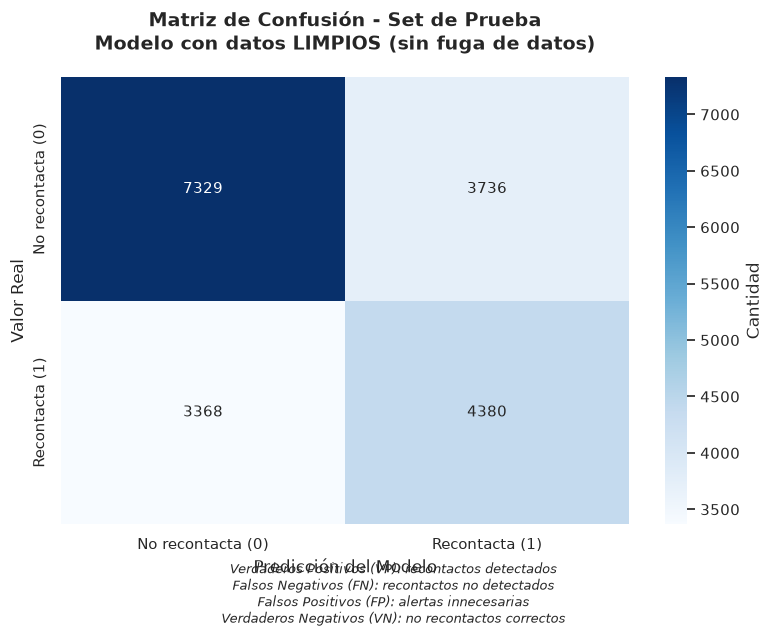


📊 DESGLOSE DE LA MATRIZ:
   • Verdaderos Positivos (VP):  4380 → recontactos detectados
   • Verdaderos Negativos (VN):  7329 → no recontactos correctos
   • Falsos Positivos (FP):      3736 → alertas innecesarias
   • Falsos Negativos (FN):      3368 → recontactos que se escapan


In [8]:
# ============================================================
# Celda 8: Matriz de confusión visual
# ============================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No recontacta (0)', 'Recontacta (1)'],
    yticklabels=['No recontacta (0)', 'Recontacta (1)'],
    cbar_kws={'label': 'Cantidad'}
)

plt.title('Matriz de Confusión - Set de Prueba\nModelo con datos LIMPIOS (sin fuga de datos)',
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Valor Real', fontsize=12)
plt.xlabel('Predicción del Modelo', fontsize=12)

plt.figtext(0.5, -0.05,
            'Verdaderos Positivos (VP): recontactos detectados\n'
            'Falsos Negativos (FN): recontactos no detectados\n'
            'Falsos Positivos (FP): alertas innecesarias\n'
            'Verdaderos Negativos (VN): no recontactos correctos',
            ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\n📊 DESGLOSE DE LA MATRIZ:")
print(f"   • Verdaderos Positivos (VP):  {tp:4d} → recontactos detectados")
print(f"   • Verdaderos Negativos (VN):  {tn:4d} → no recontactos correctos")
print(f"   • Falsos Positivos (FP):      {fp:4d} → alertas innecesarias")
print(f"   • Falsos Negativos (FN):      {fn:4d} → recontactos que se escapan")


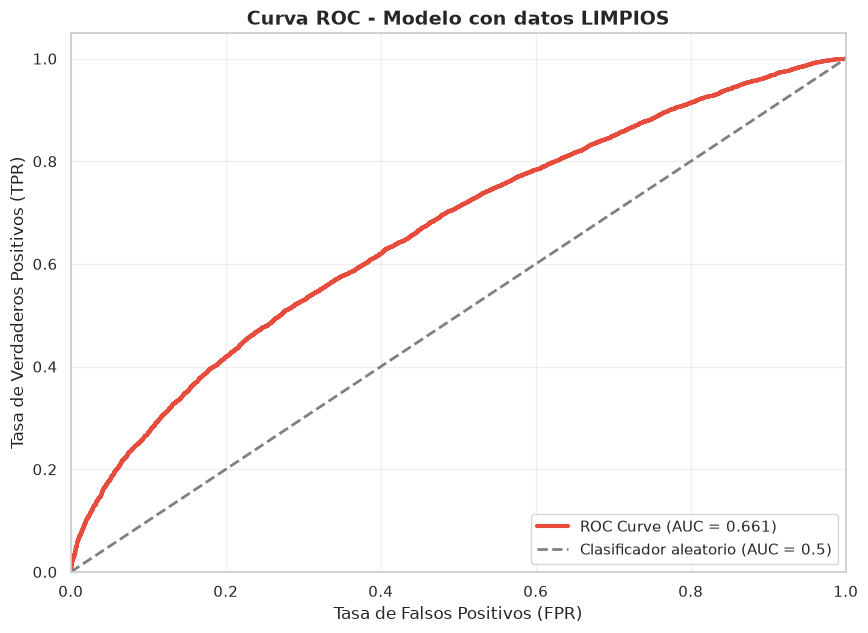


🎯 UMBRAL ÓPTIMO (Youden): 0.523
   • TPR en ese punto: 0.510
   • FPR en ese punto: 0.277
   • Para negocio: bajar el umbral permite detectar más recontactos (más recall)
     a cambio de más falsas alertas; la decisión es de Operaciones.


In [9]:
# ============================================================
# Celda 9: Curva ROC
# ============================================================
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='#e74c3c', lw=3, label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Clasificador aleatorio (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
plt.title('Curva ROC - Modelo con datos LIMPIOS', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

idx_optimo = np.argmax(tpr - fpr)
print(f"\n🎯 UMBRAL ÓPTIMO (Youden): {thresholds[idx_optimo]:.3f}")
print(f"   • TPR en ese punto: {tpr[idx_optimo]:.3f}")
print(f"   • FPR en ese punto: {fpr[idx_optimo]:.3f}")
print("   • Para negocio: bajar el umbral permite detectar más recontactos (más recall)")
print("     a cambio de más falsas alertas; la decisión es de Operaciones.")


🔍 VARIABLES MÁS IMPORTANTES DEL MODELO

📊 TOP 15 VARIABLES POR IMPORTANCIA:
----------------------------------------------------------------------
    9. es_cola_soporte                | 0.1298
    4. es_motivo_falla                | 0.1205
   19. tuvo_transferencia             | 0.1173
    8. es_cola_facturacion            | 0.0640
   10. es_cola_reclamos               | 0.0620
   17. transferencias                 | 0.0574
    7. es_motivo_queja                | 0.0562
    3. es_canal_red_social            | 0.0443
    5. es_motivo_cobro                | 0.0408
    6. es_motivo_solicitud            | 0.0396
   20. espera_larga                   | 0.0240
   11. es_cola_tramites               | 0.0221
   14. es_usuario_adulto_mayor        | 0.0198
   21. tiene_casos_previos            | 0.0197
   18. casos_previos_30d              | 0.0181


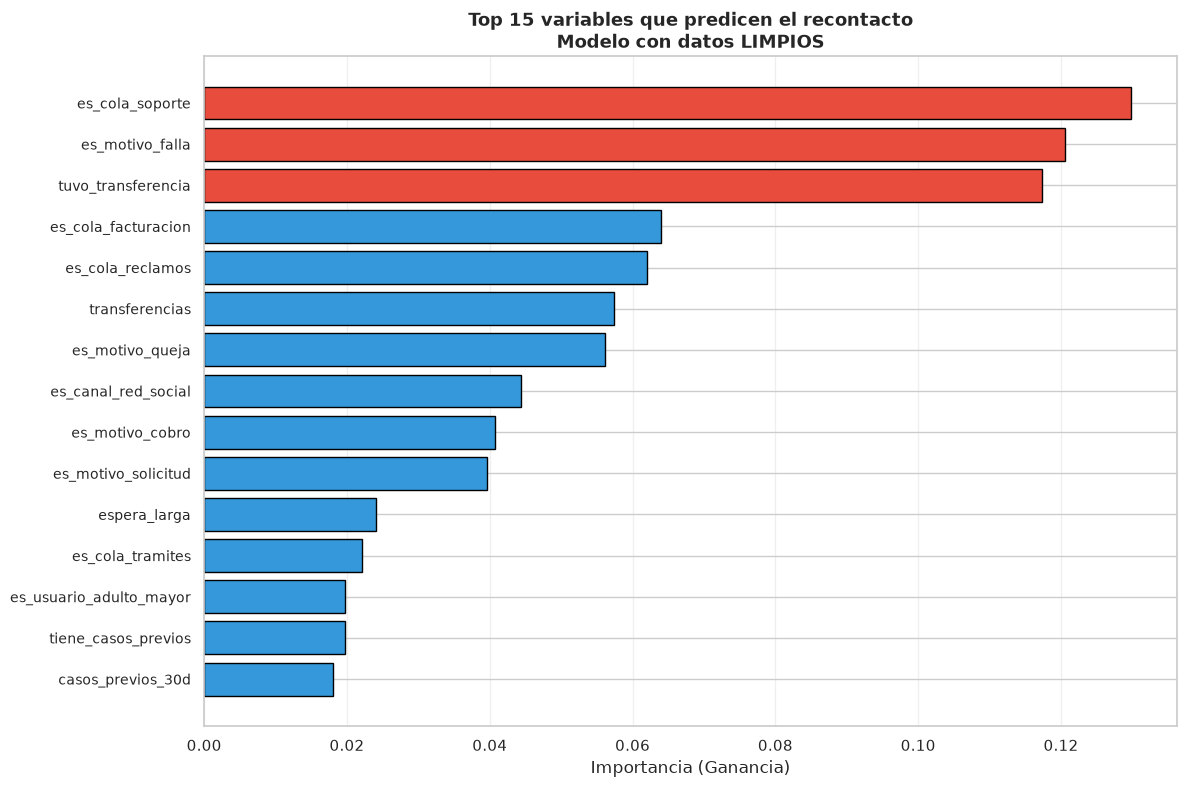


💡 TOP 3 VARIABLES:
   es_cola_soporte                | 0.1298
   es_motivo_falla                | 0.1205
   tuvo_transferencia             | 0.1173


In [10]:
# ============================================================
# Celda 10: Feature Importance
# ============================================================
print("=" * 70)
print("🔍 VARIABLES MÁS IMPORTANTES DEL MODELO")
print("=" * 70)

importancia = modelo.feature_importances_
df_importancia = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importancia
}).sort_values(by='Importancia', ascending=False)

top15 = df_importancia.head(15)
print(f"\n📊 TOP 15 VARIABLES POR IMPORTANCIA:")
print("-" * 70)
for i, row in top15.iterrows():
    print(f"   {i+1:2d}. {row['Variable']:30s} | {row['Importancia']:.4f}")

plt.figure(figsize=(12, 8))
plot_data = top15.sort_values('Importancia', ascending=True)
colors = ['#e74c3c' if i < 3 else '#3498db' for i in range(len(plot_data) - 1, -1, -1)]
plt.barh(range(len(plot_data)), plot_data['Importancia'], color=colors, edgecolor='black')
plt.yticks(range(len(plot_data)), plot_data['Variable'], fontsize=10)
plt.xlabel('Importancia (Ganancia)', fontsize=12)
plt.title('Top 15 variables que predicen el recontacto\nModelo con datos LIMPIOS',
          fontsize=13, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n💡 TOP 3 VARIABLES:")
for i, row in df_importancia.head(3).iterrows():
    print(f"   {row['Variable']:30s} | {row['Importancia']:.4f}")


In [11]:
# ============================================================
# Celda 11: Reglas de negocio accionables
# ============================================================
print("=" * 70)
print("💼 TRADUCCIÓN A ACCIONES DE NEGOCIO")
print("=" * 70)

# Tasas reales de recontacto por dimensión (calculadas del dataset limpio)
print("\n📊 TASA DE RECONTACTO REAL POR DIMENSIÓN:")
print("-" * 70)

for col in ['canal', 'motivo_contacto', 'cola_servicio', 'tipo_usuario']:
    if col in df.columns:
        tabla = df.groupby(col)['recontacto_7_dias'].agg(['mean', 'count']).sort_values('mean', ascending=False)
        print(f"\n📌 {col.upper()}:")
        for nombre, fila in tabla.iterrows():
            print(f"   • {str(nombre):15s} TR7 = {fila['mean'] * 100:5.1f}%  ({int(fila['count']):,} interacciones)")

print("\n" + "=" * 70)
print("🎯 ACCIONES RECOMENDADAS (priorizadas por evidencia):")
print("=" * 70)
print('''
   1. URGENTE - Reforzar resolución en primer contacto en los canales/motivos
      con mayor TR7 (revisar la tabla de arriba: Falla y Red social suelen
      estar por encima del promedio global).

   2. ALTO - Revisar las colas con más recontacto (Soporte y Facturación):
      puede faltar base de conocimiento (guion/FAQ) o personal capacitado.

   3. MEDIO - Para interacciones con transferencias y casos previos altos,
      disparar una alerta de "caso complejo" y asignarlo a un agente senior.

   4. MEDIO - Usar el modelo como semáforo de riesgo (umbral bajo) para
      que Calidad revise las interacciones que van a volver a recontactar.
''')


💼 TRADUCCIÓN A ACCIONES DE NEGOCIO

📊 TASA DE RECONTACTO REAL POR DIMENSIÓN:
----------------------------------------------------------------------

🎯 ACCIONES RECOMENDADAS (priorizadas por evidencia):

   1. URGENTE - Reforzar resolución en primer contacto en los canales/motivos
      con mayor TR7 (revisar la tabla de arriba: Falla y Red social suelen
      estar por encima del promedio global).

   2. ALTO - Revisar las colas con más recontacto (Soporte y Facturación):
      puede faltar base de conocimiento (guion/FAQ) o personal capacitado.

   3. MEDIO - Para interacciones con transferencias y casos previos altos,
      disparar una alerta de "caso complejo" y asignarlo a un agente senior.

   4. MEDIO - Usar el modelo como semáforo de riesgo (umbral bajo) para
      que Calidad revise las interacciones que van a volver a recontactar.



In [12]:
# ============================================================
# Celda 12: Reporte ejecutivo para la Gerencia de Servicio
# ============================================================
print("=" * 70)
print("📊 REPORTE EJECUTIVO FINAL")
print("Modelo Predictivo de Recontacto - Servicio Ciudadano 1800")
print("=" * 70)

print(f'''
🎯 OBJETIVO DEL PROYECTO:
   Bajar la Tasa de Recontacto a 7 días (TR7) del 41.13% al 22% o menos.

📊 DATASET UTILIZADO:
   • Tabla: dm_dataset_recontacto_correcto (v1, limpio)
   • Registros: {len(df):,}
   • Variables: {X.shape[1]} features
   • CRÍTICO: construido después del MINI ETL (sin duplicados, etiquetas
     normalizadas, medidas en rango) y sin fuga de datos.

🤖 MODELO ENTRENADO:
   • Algoritmo: XGBoost Classifier
   • Hiperparámetros: n_estimators=600, max_depth=5, lr=0.05
   • Corrección de desbalance: scale_pos_weight={ratio_desbalance:.2f}

📈 MÉTRICAS DE RENDIMIENTO:
   • Accuracy:      {accuracy:.2%}
   • ROC-AUC:       {auc:.4f}
   • Avg Precision: {avg_precision:.4f}

🔍 TOP 3 VARIABLES PREDICTIVAS:
   1. {df_importancia.iloc[0]['Variable']:30s} ({df_importancia.iloc[0]['Importancia']:.4f})
   2. {df_importancia.iloc[1]['Variable']:30s} ({df_importancia.iloc[1]['Importancia']:.4f})
   3. {df_importancia.iloc[2]['Variable']:30s} ({df_importancia.iloc[2]['Importancia']:.4f})

📋 PRÓXIMOS PASOS:
   1. Validar el umbral de decisión con Operaciones (costo de falsa alarma).
   2. Pilotear alertas de riesgo en 1 cola durante 4 semanas.
   3. Reentrenar cada 3 meses con datos nuevos.
   4. Completar la consolidación de recontacto_7_dias (hoy hay ventanas abiertas).

⚠️ LIMITACIONES:
   • Datos sintéticos basados en el expediente del caso (360 registros).
   • El recontacto depende de factores externos que el dataset no recoge.
   • Los vacíos de recontacto_7_dias son no consolidados, no "no recontacta".
''')

print("=" * 70)
print("✅ ANÁLISIS COMPLETADO")
print("=" * 70)


📊 REPORTE EJECUTIVO FINAL
Modelo Predictivo de Recontacto - Servicio Ciudadano 1800

🎯 OBJETIVO DEL PROYECTO:
   Bajar la Tasa de Recontacto a 7 días (TR7) del 41.13% al 22% o menos.

📊 DATASET UTILIZADO:
   • Tabla: dm_dataset_recontacto_correcto (v1, limpio)
   • Registros: 94,065
   • Variables: 26 features
   • CRÍTICO: construido después del MINI ETL (sin duplicados, etiquetas
     normalizadas, medidas en rango) y sin fuga de datos.

🤖 MODELO ENTRENADO:
   • Algoritmo: XGBoost Classifier
   • Hiperparámetros: n_estimators=600, max_depth=5, lr=0.05
   • Corrección de desbalance: scale_pos_weight=1.43

📈 MÉTRICAS DE RENDIMIENTO:
   • Accuracy:      62.24%
   • ROC-AUC:       0.6611
   • Avg Precision: 0.5889

🔍 TOP 3 VARIABLES PREDICTIVAS:
   1. es_cola_soporte                (0.1298)
   2. es_motivo_falla                (0.1205)
   3. tuvo_transferencia             (0.1173)

📋 PRÓXIMOS PASOS:
   1. Validar el umbral de decisión con Operaciones (costo de falsa alarma).
   2. Pilote